# Trabajo práctico: probabilidad y decisiones

**Nombre:** Nuria Desteffani

**Curso:** Data Science - Semana 4, clase 4

**Dataset:** Bank Marketing (`bank.csv`), muestra del 10 % de `bank-full.csv`

**Fuente:** Moro, S., Rita, P. y Cortez, P. (2014). *Bank Marketing*. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306. Licencia CC BY 4.0.


## 1. Preparar los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

datos = pd.read_csv("bank.csv", sep=";")
print(datos.shape)
datos.head()

(4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [2]:
datos.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

**Definiciones para este trabajo**

| Elemento | Definición para este trabajo |
|---|---|
| Unidad de análisis | un registro de cliente dentro de la campaña |
| Población registrada | los registros incluidos en bank.csv |
| Evento de interés, S | el registro tiene y = "yes" |
| Denominador | registros con un valor válido en y |

`bank.csv` es una muestra aleatoria del 10 % de `bank-full.csv`. La proporción calculada sobre todo `bank.csv` es la referencia observada para comparar las muestras más pequeñas.

## 2. Revisar y describir

In [3]:
print("Filas duplicadas:", datos.duplicated().sum())
print()
print("Valores faltantes por columna:")
print(datos.isna().sum())

Filas duplicadas: 0

Valores faltantes por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


### Variable `y`

In [4]:
frec_y = datos["y"].value_counts()
pct_y = datos["y"].value_counts(normalize=True) * 100
resumen_y = pd.DataFrame({"Frecuencia": frec_y, "Porcentaje (%)": pct_y.round(2)})
resumen_y

,Frecuencia,Porcentaje (%)
y,,
no,4000,88.48
yes,521,11.52


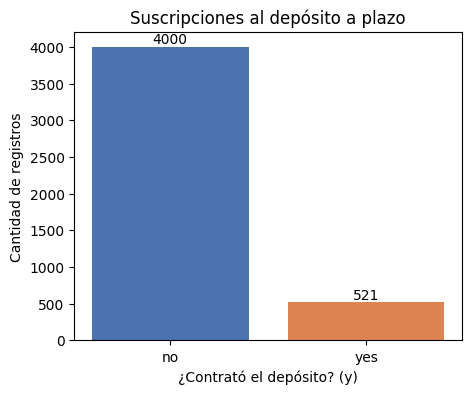

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
barras = ax.bar(frec_y.index, frec_y.values, color=["#4C72B0", "#DD8452"])
ax.bar_label(barras)
ax.set_title("Suscripciones al depósito a plazo")
ax.set_xlabel("¿Contrató el depósito? (y)")
ax.set_ylabel("Cantidad de registros")
plt.show()

### Variable `campaign`

In [6]:
resumen_campaign = datos["campaign"].describe()[["min", "25%", "50%", "75%", "max"]]
resumen_campaign

min     1.0
25%     1.0
50%     2.0
75%     3.0
max    50.0
Name: campaign, dtype: float64

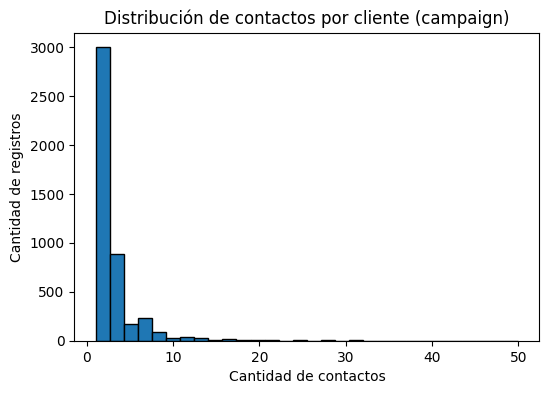

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(datos["campaign"], bins=30, edgecolor="black")
ax.set_title("Distribución de contactos por cliente (campaign)")
ax.set_xlabel("Cantidad de contactos")
ax.set_ylabel("Cantidad de registros")
plt.show()

**Forma de la distribución:** la mayoría de los registros tiene entre 1 y 3 contactos (la mediana es 2 y el tercer cuartil es 3), y la distribución muestra una fuerte asimetría hacia la derecha: unos pocos clientes fueron contactados muchas veces, hasta un máximo de 50 contactos, muy alejado del resto de los valores.

## 3. Calcular la proporción observada

In [8]:
validos = datos["y"].notna().sum()
suscripciones = (datos["y"] == "yes").sum()
no_suscripciones = validos - suscripciones

p_s = suscripciones / validos
p_sc = no_suscripciones / validos

print(f"P(S)   = {suscripciones} / {validos} = {p_s:.4f} = {p_s*100:.2f} %")
print(f"P(S^c) = {no_suscripciones} / {validos} = {p_sc:.4f} = {p_sc*100:.2f} %")
print("¿Suman 1?", round(p_s + p_sc, 10) == 1)

P(S)   = 521 / 4521 = 0.1152 = 11.52 %
P(S^c) = 4000 / 4521 = 0.8848 = 88.48 %
¿Suman 1? True


**Resultado:** se observa que 521 de los 4.521 registros válidos terminaron en suscripción: P(S) = 521 / 4521 = 0,1152 = 11,52 %. El complemento es P(Sᶜ) = 4000 / 4521 = 0,8848 = 88,48 %. Ambas proporciones suman 1, como corresponde a eventos complementarios.

## 4. Observar la variabilidad entre muestras

In [9]:
filas = []
for semilla in [1, 2, 3, 4, 5]:
    muestra = datos.sample(n=300, replace=False, random_state=semilla)
    s = (muestra["y"] == "yes").sum()
    filas.append({"Semilla": semilla, "Suscripciones": s,
                  "Tamaño de muestra": 300, "Proporción": round(s / 300, 4)})

tabla_muestras = pd.DataFrame(filas)
tabla_muestras

,Semilla,Suscripciones,Tamaño de muestra,Proporción
0,1,41,300,0.1367
1,2,28,300,0.0933
2,3,26,300,0.0867
3,4,31,300,0.1033
4,5,31,300,0.1033


In [10]:
prop_min = tabla_muestras["Proporción"].min()
prop_max = tabla_muestras["Proporción"].max()
diferencia = prop_max - prop_min

idx_cercana = (tabla_muestras["Proporción"] - p_s).abs().idxmin()
semilla_cercana = tabla_muestras.loc[idx_cercana, "Semilla"]

print(f"Proporción mínima: {prop_min:.4f} ({prop_min*100:.2f} %)")
print(f"Proporción máxima: {prop_max:.4f} ({prop_max*100:.2f} %)")
print(f"Diferencia: {diferencia:.4f} ({diferencia*100:.2f} puntos porcentuales)")
print(f"Semilla más cercana a P(S) observado ({p_s:.4f}): semilla {semilla_cercana}")

Proporción mínima: 0.0867 (8.67 %)
Proporción máxima: 0.1367 (13.67 %)
Diferencia: 0.0500 (5.00 puntos porcentuales)
Semilla más cercana a P(S) observado (0.1152): semilla 4


**Respuestas:**

1. La proporción mínima fue 0,0867 (8,67 %, semilla 3) y la máxima fue 0,1367 (13,67 %, semilla 1).
2. La diferencia entre ambas fue de 0,0500, es decir, 5 puntos porcentuales.
3. La muestra de la semilla 4 (10,33 %) quedó más cerca de la proporción observada en todo `bank.csv` (11,52 %).
4. Las cinco estimaciones pueden ser distintas aunque provengan del mismo archivo porque cada muestra de 300 registros es un subconjunto aleatorio diferente: por azar, cada subconjunto puede contener una proporción algo mayor o menor de clientes que dijeron "yes". Esto es variabilidad muestral, no un error de cálculo: al achicar el tamaño de la muestra respecto de la población completa, la estimación se aleja más fácilmente del valor observado en el archivo completo.

## 5. Tomar una decisión sencilla

In [11]:
costo_contacto = 1
beneficio_suscripcion = 12

valor_esperado_contacto = beneficio_suscripcion * p_s - costo_contacto
valor_esperado_piloto = valor_esperado_contacto * 100

print(f"Valor esperado neto por contacto = 12 × {p_s:.4f} - 1 = {valor_esperado_contacto:.4f}")
print(f"Valor esperado neto para 100 contactos = {valor_esperado_piloto:.2f}")

Valor esperado neto por contacto = 12 × 0.1152 - 1 = 0.3829
Valor esperado neto para 100 contactos = 38.29


**Interpretación:**

1. El valor esperado neto por contacto es 12 × 0,1152 − 1 = 0,3829. En promedio, cada contacto realizado deja una ganancia neta esperada de aproximadamente 0,38 unidades, considerando el beneficio de una eventual suscripción y el costo fijo del contacto.
2. Para una prueba piloto de 100 contactos, el valor esperado neto es 100 × 0,3829 ≈ 38,29 unidades.
3. Como el valor esperado neto por contacto es positivo (0,3829 > 0), y muy por encima del punto de equilibrio (P(S) = 1/12 ≈ 8,33 %, mientras que la proporción observada es 11,52 %), sí se recomienda realizar la prueba piloto: en promedio, la campaña generaría ganancia. Esto supone que la tasa de suscripción de la campaña futura se mantendrá similar a la observada en `bank.csv`.

## 6. Cierre

1. **Proporción observada:** se observa que 521 de los 4.521 registros de `bank.csv` terminaron en suscripción (521 / 4521 = 11,52 %).
2. **Variación entre muestras:** la muestra indica que, al tomar cinco muestras aleatorias de 300 registros, la proporción de suscripción varió entre 8,67 % y 13,67 %, una diferencia de 5 puntos porcentuales respecto de la proporción observada en el archivo completo.
3. **Decisión propuesta:** se propone realizar la prueba piloto de 100 contactos, ya que el valor esperado neto por contacto (0,38 unidades) es positivo. El supuesto principal que sostiene esta decisión es que la proporción de suscripción de la campaña futura se comportará de manera similar a la observada en los registros analizados.